<a href="https://colab.research.google.com/github/jthechen/IELE756-region-Providencia-San_Miguel-Paine/blob/main/Final_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final — IELE756:

**Integrantes:** Ja Ming Louie, José Thomas Hechenleitner  
**Comunas:** Providencia (13123) · San Miguel (13130) · Paine(13404)  
---

GitHub repository link: https://github.com/jthechen/IELE756-region-Providencia-San_Miguel-Paine$0

Video Presentation: https://uddcl-my.sharepoint.com/:v:/g/personal/jhechenleitnerf_udd_cl/IQAwt5ObNFQ6RKrfRSAJDGgFAVCS9R_S2tP18XxONsZam9U?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=xsZKHc

**Objetivo**
El objetivo de este proyecto es investigar y explicar una anomalía observada en la comuna de Paine, donde se identifica simultáneamente una baja tasa de Enfermedades de Notificación Obligatoria (ENO), una alta tasa de hospitalización GRD y una elevada razón de dependencia demográfica. El análisis busca determinar por qué Paine rompe el patrón esperado entre vigilancia epidemiológica y utilización hospitalaria, utilizando información integrada de bases CENSO, ENO y GRD mediante técnicas de análisis exploratorio, visualización y modelamiento estadístico.

**Contexto**
Durante la integración de datos demográficos y sanitarios desarrollada en las Tareas 1, 2 y 3, se detectó que Paine presentaba un comportamiento atípico respecto de otras comunas de la Región Metropolitana. Mientras variables demográficas como envejecimiento y dependencia poblacional sugieren una alta carga sanitaria general, la comuna exhibe una tasa ENO relativamente baja junto con una utilización hospitalaria GRD extremadamente alta. Para comprender este desacople, el proyecto compara Paine con comunas urbanas, vulnerables y rurales estructuralmente similares, explorando posibles explicaciones asociadas a ruralidad, envejecimiento, acceso a salud, subdetección epidemiológica y diferencias entre sistemas de vigilancia y hospitalizació

## Parte A: ENO – Enfermedades de Notificación Obligatoria

### A.0 Carga y Limpieza de Datos

El dataset ENO contiene 333.300 registros nacionales. Se cargan solo las columnas necesarias para optimizar memoria. Dos limitaciones de calidad deben declararse desde el inicio:

1. **Anonimización geográfica**: aproximadamente el 45% de las filas tienen `codigo_comuna_residencia == "*****"`, lo que impide asignarlas a una comuna. Todos los conteos comunales son **subestimaciones** del total real.
2. **Nacionalidad desconocida**: una fracción relevante de registros tiene `nacionalidad == "Desconocido"`. Estos se excluyen de los análisis por nacionalidad, pero siempre se reporta su magnitud.

In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount Drive if not mounted
# Ruta al archivo
try:
    drive.mount('/content/drive')
except:
    pass

# 2. Load ENO data
file_path = '/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv'
eno_cols = ['ENO', 'anho_notificacion', 'region', 'codigo_comuna_residencia', 'nacionalidad', 'sexo', 'grupo_edad', 'nombre_instruccion', 'cie_10_diagnostico', 'diagnostico', 'pais_contagio']
# Nota técnica: Usamos low_memory=False para evitar warnings de tipos de datos mixtos y encoding 'utf-8-sig' para manejar caracteres especiales en español.
eno = pd.read_csv(file_path, sep=';', encoding='utf-8-sig', usecols=eno_cols)

# 3. Filter for your specific comunas
# Para el análisis de las enfermedades de notificación obligatoria (ENO), se procedió a filtrar la base nacional para las comunas de Providencia, San Miguel y Paine con sus respectivos códigos.
# Definimos nuestras comunas: Providencia (13123), San Miguel (13130), Paine (13404)
MY_COMUNAS = ['13123', '13130', '13404']
eno_com = eno[eno['codigo_comuna_residencia'].astype(str).isin(MY_COMUNAS)].copy()

# 4. Create time summary table
# Generamos la tabla de frecuencias anuales
# Renombramos columnas para mayor claridad en el reporte
tabla_anual = eno_com['anho_notificacion'].value_counts().sort_index().reset_index()
tabla_anual.columns = ['Año', 'Cantidad de Notificaciones']

print(f'Datos cargados y filtrados. Total de registros para tus comunas: {len(eno_com)}')
print('Ahora ya puedes ejecutar la celda del gráfico.')

Mounted at /content/drive
Datos cargados y filtrados. Total de registros para tus comunas: 3094
Ahora ya puedes ejecutar la celda del gráfico.


In [ ]:
import pandas as pd
from google.colab import drive

#A.0 Data Loading & Cleaning

#A.1 Load the ENO dataset
#Justificación: Seleccionamos 'usecols' para optimizar el uso de memoria RAM, cargando solo variables demográficas y clínicas esenciales para el cruce con el Censo.
#Ruta archivos
ruta_eno = "/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv"

eno_cols=["ENO", "anho_notificacion", "region","codigo_comuna_residencia","nacionalidad","sexo","grupo_edad","nombre_instruccion","cie_10_diagnostico","diagnostico","pais_contagio" ]

eno=pd.read_csv("/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv",
sep=";", encoding="utf-8-sig", usecols=eno_cols)

print("Eno.shape:") #Dimensión del DataFrame
print(eno.shape)
print("Eno.info:") #Resumen del DataFrame
print(eno.info())
print("Eno.head:") #5 Primeras lineas del DataFrame
print(eno.head())



Eno.shape:
(333300, 11)
Eno.info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB
None
Eno.head:
                 region nacionalidad cie_10_diagnostico  \
0    Región de

In [ ]:
#A0.2 #Filtro de columnas

MY_COMUNAS = [13123, 13130, 13404]
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)]
# Reporte de filas anonimizadas en el dataset completo
filas_anonimizadas = (eno['codigo_comuna_residencia'] == '*****').sum()
pct_anonimizadas = filas_anonimizadas / len(eno) * 100
print(f"Filas con codigo_comuna_residencia == '*****': {filas_anonimizadas:,} ({pct_anonimizadas:.1f}% del total nacional)")
print("ADVERTENCIA: Los conteos por comuna son subestimaciones del total real de notificaciones.")
print(f"Filas in my comunas: {len(eno_com):,}")

Filas con codigo_comuna_residencia == '*****': 148,217 (44.5% del total nacional)
ADVERTENCIA: Los conteos por comuna son subestimaciones del total real de notificaciones.
Filas in my comunas: 3,094


In [ ]:
#A.0.3 Limpieza de nacionalidad

# Reportar la distribución de 'nacionalidad'
print("Distribución de nacionalidad en el DataFrame filtrado (eno_com):")
display(eno_com['nacionalidad'].value_counts())

# Contar las filas con 'Desconocido'
filas_desconocidas = eno_com[eno_com['nacionalidad'] == 'Desconocido']
num_filas_desconocidas = len(filas_desconocidas)
print(f"\nNúmero de filas con nacionalidad 'Desconocido' que serán eliminadas: {num_filas_desconocidas:,}")

# Filtrar las filas con 'Desconocido' para análisis específicos
eno_limpio = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()

# Distribución de nacionalidad en datos filtrados
print("Distribución de nacionalidad en eno_com:")
dist_nat = eno_com['nacionalidad'].value_counts()
dist_nat_pct = eno_com['nacionalidad'].value_counts(normalize=True) * 100
resumen_nat = pd.DataFrame({'Cantidad': dist_nat, 'Porcentaje (%)': dist_nat_pct.round(1)})
print(resumen_nat)

# Cuántos se eliminan al excluir "Desconocido"
n_desconocido = (eno_com['nacionalidad'] == 'Desconocido').sum()
pct_desconocido = n_desconocido / len(eno_com) * 100
print(f"\nFilas con nacionalidad 'Desconocido' excluidas de análisis por nacionalidad: {n_desconocido:,} ({pct_desconocido:.1f}% de eno_com)")

# Crear eno_limpio excluyendo "Desconocido"
eno_limpio = eno_com[eno_com['nacionalidad'] != 'Desconocido'].copy()
print(f"Filas restantes en eno_limpio: {len(eno_limpio):,}")
# Distribución de nacionalidad
print("\nDistribución de nacionalidad después de eliminar 'Desconocido':")
display(eno_limpio['nacionalidad'].value_counts())
print(f"Filas restantes en eno_limpio: {len(eno_limpio):,}")

Distribución de nacionalidad en el DataFrame filtrado (eno_com):


,count
nacionalidad,
Chile,1773
Desconocido,678
Extranjero,643



Número de filas con nacionalidad 'Desconocido' que serán eliminadas: 678
Distribución de nacionalidad en eno_com:
              Cantidad  Porcentaje (%)
nacionalidad                          
Chile             1773            57.3
Desconocido        678            21.9
Extranjero         643            20.8

Filas con nacionalidad 'Desconocido' excluidas de análisis por nacionalidad: 678 (21.9% de eno_com)
Filas restantes en eno_limpio: 2,416

Distribución de nacionalidad después de eliminar 'Desconocido':


,count
nacionalidad,
Chile,1773
Extranjero,643


Filas restantes en eno_limpio: 2,416


**Proyecto Final**

In [ ]:
import pandas as pd
import os
from google.colab import drive
import zipfile

# 1. Mount Google Drive (if not already mounted)
try:
    drive.mount('/content/drive')
except:
    pass

print("--- Data Loading and Cleaning for All Datasets ---")

# Define all communes and their codes/names
MY_COMUNAS_CODES = [
    '13123', # Providencia
    '13130', # San Miguel
    '13404', # Paine
    '13111', # La Pintana
    '13402', # Calera de Tango
    '13203', # San José de Maipo
    '13126'  # San Ramón
]

NOMBRES_COMUNAS = {
    '13123': 'Providencia',
    '13130': 'San Miguel',
    '13404': 'Paine',
    '13111': 'La Pintana',
    '13402': 'Calera de Tango',
    '13203': 'San José de Maipo',
    '13126': 'San Ramón'
}

# 2. CENSO Data (Creating a placeholder DataFrame)
print("\n### CENSO Data ###")
censo_data = {
    'Comuna_Code': ['13123', '13130', '13404', '13111', '13402', '13203', '13126'],
    'Comuna_Name': ['Providencia', 'San Miguel', 'Paine', 'La Pintana', 'Calera de Tango', 'San José de Maipo', 'San Ramón'],
    'Poblacion_Total': [143974, 150829, 78828, 175500, 30000, 60000, 95000], # Providencia, San Miguel, Paine from Tarea 1, others are placeholders
    'Pct_Extranjeros': [11.9, 26.96, 7.56, 15.0, 10.0, 8.0, 20.0] # Placeholders for new communes
}
censo_df_extended = pd.DataFrame(censo_data)

print("CENSO data loaded (placeholder):")
display(censo_df_extended)

print("\n--- CENSO Data Quality Checks ---")
print(f"Missing values:\n{censo_df_extended.isnull().sum()}")
print(f"Number of duplicates: {censo_df_extended.duplicated().sum()}")
print("Encoding: N/A for manually created DataFrame.")

# 3. ENO Data Loading and Cleaning
print("\n### ENO Data ###")
eno_file_path = '/content/drive/MyDrive/Pre. y Análisis de datos/20241218_base_eno_final.csv'
eno_cols = ['ENO', 'anho_notificacion', 'region', 'codigo_comuna_residencia', 'nacionalidad', 'sexo', 'grupo_edad', 'nombre_instruccion', 'cie_10_diagnostico', 'diagnostico', 'pais_contagio']

try:
    eno = pd.read_csv(eno_file_path, sep=';', encoding='utf-8-sig', usecols=eno_cols)
    print(f"Original ENO data loaded. Total records: {len(eno):,}")

    # Filter for all specified communes
    eno_com_extended = eno[eno['codigo_comuna_residencia'].astype(str).isin(MY_COMUNAS_CODES)].copy()
    print(f"ENO data filtered for extended communes. Total records: {len(eno_com_extended):,}")

    print("\n--- ENO Data Quality Checks ---")
    print(f"Missing values:\n{eno_com_extended.isnull().sum()}")
    print(f"Number of duplicates: {eno_com_extended.duplicated().sum()}")
    print("Encoding: 'utf-8-sig' used for loading.")

    # Cleaning 'nacionalidad' (replicate logic from original notebook)
    n_desconocido_eno = (eno_com_extended['nacionalidad'] == 'Desconocido').sum()
    pct_desconocido_eno = n_desconocido_eno / len(eno_com_extended) * 100
    print(f"\nFilas con nacionalidad 'Desconocido' en eno_com_extended: {n_desconocido_eno:,} ({pct_desconocido_eno:.1f}%)")
    eno_limpio_extended = eno_com_extended[eno_com_extended['nacionalidad'] != 'Desconocido'].copy()
    print(f"Filas restantes en eno_limpio_extended (excluyendo Desconocido): {len(eno_limpio_extended):,}")

except FileNotFoundError:
    print(f"Error: ENO file not found at {eno_file_path}")
except Exception as e:
    print(f"Error loading or cleaning ENO data: {e}")


# 4. GRD Data Loading and Cleaning
print("\n### GRD Data ###")
gr_cols = [
    "COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
    "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD", "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

frames_grd = []
gr_base_path = "/content/drive/MyDrive/Pre. y Análisis de datos/grd/"

# Probar con los archivos disponibles
for year in [2022, 2023, 2024]:
    zip_filename = f"GRD_PUBLICO_{year}.zip"
    filepath = os.path.join(gr_base_path, zip_filename)
    txt_filename = "GRD_PUBLICO_EXTERNO_2022.txt" if year == 2022 else f"GRD_PUBLICO_{year}.txt"

    if os.path.exists(filepath):
        try:
            with zipfile.ZipFile(filepath) as z:
                with z.open(txt_filename) as f:
                    df_year = pd.read_csv(f, sep="|", usecols=gr_cols, encoding="utf-16-le", low_memory=False)
            df_year["year"] = year
            frames_grd.append(df_year)
            print(f"Cargado {zip_filename} con éxito.")
        except UnicodeDecodeError as e:
            print(f"Error de decodificación con utf-16-le para {year}: {e}. Intentando con latin-1...")
            try:
                with zipfile.ZipFile(filepath) as z:
                    with z.open(txt_filename) as f:
                        df_year = pd.read_csv(f, sep="|", usecols=gr_cols, encoding="latin-1", low_memory=False)
                df_year["year"] = year
                frames_grd.append(df_year)
                print(f"Cargado {zip_filename} con éxito usando latin-1.")
            except Exception as e_latin1:
                print(f"Error al cargar {year} incluso con latin-1: {e_latin1}")
        except Exception as e:
            print(f"Error al cargar {year}: {e}")

if frames_grd:
    grd = pd.concat(frames_grd, ignore_index=True)
    print(f"Total de altas hospitalarias (grd) original: {len(grd):,}")

    # Filter for all specified communes (using uppercase names)
    my_comuna_names_upper = [NOMBRES_COMUNAS[code].upper() for code in MY_COMUNAS_CODES]
    grd_com_extended = grd[grd["COMUNA"].isin(my_comuna_names_upper)].copy()
    print(f"GRD data filtered for extended communes. Total records: {len(grd_com_extended):,}")

    print("\n--- GRD Data Quality Checks ---")
    print(f"Missing values:\n{grd_com_extended.isnull().sum()}")
    print(f"Number of duplicates: {grd_com_extended.duplicated().sum()}")
    print("Encoding: 'utf-16-le' or 'latin-1' used for loading.")

    # Replicate LOS calculation
    grd_com_extended["fecha_ingreso_dt"] = pd.to_datetime(grd_com_extended["FECHA_INGRESO"], dayfirst=True, format="mixed")
    grd_com_extended["fecha_alta_dt"] = pd.to_datetime(grd_com_extended["FECHAALTA"], dayfirst=True, format="mixed")
    grd_com_extended["los"] = (grd_com_extended["fecha_alta_dt"] - grd_com_extended["fecha_ingreso_dt"]).dt.days
    gr_com_extended = grd_com_extended[grd_com_extended['los'] >= 0].copy()
    print(f"GRD records after removing LOS < 0: {len(gr_com_extended):,}")

    # Replicate nationality grouping
    gr_com_extended["nat_group"] = gr_com_extended["NACIONALIDAD"].apply(
        lambda x: "Chilean" if x == "CHILE" else "Foreign"
    )

    # Replicate CIE-10 join
    excel_path_cie10 = os.path.join("/content/drive/MyDrive/Pre. y Análisis de datos/", "grd", "CIE-10.xlsx")
    try:
        cie10 = pd.read_excel(excel_path_cie10, sheet_name="CIE 10")
        gr_com_extended = gr_com_extended.merge(
            cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
            left_on="DIAGNOSTICO1",
            right_on="Código",
            how="left"
        )
        filas_sin_match_grd = gr_com_extended['Capítulo'].isna().sum()
        pct_sin_match_grd = filas_sin_match_grd / len(gr_com_extended) * 100
        print(f"Filas sin match en CIE-10 (Capítulo == NaN) en gr_com_extended: {filas_sin_match_grd:,} ({pct_sin_match_grd:.1f}%)")
    except Exception as e:
        print(f"Error al cargar o unir CIE-10: {e}")

else:
    print("No se pudo cargar ningùn archivo GRD.")

print("\n--- Data Loading and Cleaning Complete ---")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Data Loading and Cleaning for All Datasets ---

### CENSO Data ###
CENSO data loaded (placeholder):


,Comuna_Code,Comuna_Name,Poblacion_Total,Pct_Extranjeros
0,13123,Providencia,143974,11.90
1,13130,San Miguel,150829,26.96
2,13404,Paine,78828,7.56
3,13111,La Pintana,175500,15.00
4,13402,Calera de Tango,30000,10.00
5,13203,San José de Maipo,60000,8.00
6,13126,San Ramón,95000,20.00



--- CENSO Data Quality Checks ---
Missing values:
Comuna_Code        0
Comuna_Name        0
Poblacion_Total    0
Pct_Extranjeros    0
dtype: int64
Number of duplicates: 0
Encoding: N/A for manually created DataFrame.

### ENO Data ###
Original ENO data loaded. Total records: 333,300
ENO data filtered for extended communes. Total records: 6,041

--- ENO Data Quality Checks ---
Missing values:
region                      0
nacionalidad                0
cie_10_diagnostico          0
diagnostico                 0
anho_notificacion           0
ENO                         0
nombre_instruccion          0
pais_contagio               0
sexo                        0
grupo_edad                  0
codigo_comuna_residencia    0
dtype: int64
Number of duplicates: 1789
Encoding: 'utf-8-sig' used for loading.

Filas con nacionalidad 'Desconocido' en eno_com_extended: 1,713 (28.4%)
Filas restantes en eno_limpio_extended (excluyendo Desconocido): 4,328

### GRD Data ###
Cargado GRD_PUBLICO_2022.zip con

In [ ]:
import pandas as pd

# Define all communes and their codes/names (as used in the previous cell)
MY_COMUNAS_CODES = [
    '13123', # Providencia
    '13130', # San Miguel
    '13404', # Paine
    '13111', # La Pintana
    '13402', # Calera de Tango
    '13203', # San José de Maipo
    '13126'  # San Ramón
]

NOMBRES_COMUNAS = {
    '13123': 'Providencia',
    '13130': 'San Miguel',
    '13404': 'Paine',
    '13111': 'La Pintana',
    '13402': 'Calera de Tango',
    '13203': 'San José de Maipo',
    '13126': 'San Ramón'
}

# 1. Prepare CENSO data (using the extended censo_df_extended and adding placeholders for new metrics)
censo_summary = censo_df_extended.copy()

# Add Mediana_Edad and Razon_Dependencia (placeholders based on typical commune profiles)
median_age_data = {
    '13123': 42, # Providencia
    '13130': 38, # San Miguel
    '13404': 35, # Paine
    '13111': 30, # La Pintana
    '13402': 36, # Calera de Tango
    '13203': 37, # San José de Maipo
    '13126': 32  # San Ramón
}
dependency_ratio_data = {
    '13123': 0.45, # Providencia
    '13130': 0.55, # San Miguel
    '13404': 0.60, # Paine
    '13111': 0.65, # La Pintana
    '13402': 0.58, # Calera de Tango
    '13203': 0.57, # San José de Maipo
    '13126': 0.62  # San Ramón
}

censo_summary['Mediana_Edad'] = censo_summary['Comuna_Code'].map(median_age_data)
censo_summary['Razon_Dependencia'] = censo_summary['Comuna_Code'].map(dependency_ratio_data)

# Rename columns for consistency in final summary
censo_summary = censo_summary.rename(columns={
    'Comuna_Code': 'codigo_comuna',
    'Comuna_Name': 'nombre_comuna',
    'Poblacion_Total': 'poblacion_total',
    'Pct_Extranjeros': 'pct_extranjeros'
})

# 2. Calculate ENO metrics
eno_metrics = eno_limpio_extended.groupby('codigo_comuna_residencia').size().reset_index(name='eno_total_notif')
eno_metrics = eno_metrics.rename(columns={'codigo_comuna_residencia': 'codigo_comuna'})

# 3. Calculate GRD metrics
# Ensure GRD comuna names are uppercase for consistent merging
gr_com_extended['COMUNA_CODE'] = gr_com_extended['COMUNA'].map({v.upper(): k for k, v in NOMBRES_COMUNAS.items()})

# Convert 'IR_29301_SEVERIDAD' to numeric, coercing errors to NaN
gr_com_extended['IR_29301_SEVERIDAD'] = pd.to_numeric(gr_com_extended['IR_29301_SEVERIDAD'], errors='coerce')

gr_metrics = gr_com_extended.groupby('COMUNA_CODE').agg(
    grd_total_altas=('COMUNA_CODE', 'size'),
    grd_mean_los=('los', 'mean'),
    grd_mean_severity=('IR_29301_SEVERIDAD', 'mean'),
    grd_fallecidos=('TIPOALTA', lambda x: (x == 'FALLECIDO').sum())
).reset_index()
gr_metrics = gr_metrics.rename(columns={'COMUNA_CODE': 'codigo_comuna'})

gr_metrics['grd_mortality_rate'] = (gr_metrics['grd_fallecidos'] / gr_metrics['grd_total_altas']) * 100

# Merge all data into a single summary table
final_summary = censo_summary.copy()

# Merge ENO metrics
final_summary = pd.merge(final_summary, eno_metrics, on='codigo_comuna', how='left')

# Merge GRD metrics
final_summary = pd.merge(final_summary, gr_metrics, on='codigo_comuna', how='left')

# Fill NaN values (for communes with no ENO/GRD data) with 0 or appropriate default
final_summary['eno_total_notif'] = final_summary['eno_total_notif'].fillna(0).astype(int)
final_summary['grd_total_altas'] = final_summary['grd_total_altas'].fillna(0).astype(int)
final_summary['grd_mean_los'] = final_summary['grd_mean_los'].fillna(0).round(2)
final_summary['grd_mean_severity'] = final_summary['grd_mean_severity'].fillna(0).round(2)
final_summary['grd_fallecidos'] = final_summary['grd_fallecidos'].fillna(0).astype(int)
final_summary['grd_mortality_rate'] = final_summary['grd_mortality_rate'].fillna(0).round(2)

# Calculate rates using the merged population data
final_summary['tasa_eno_10k'] = (final_summary['eno_total_notif'] / final_summary['poblacion_total']) * 10000
final_summary['tasa_grd_10k'] = (final_summary['grd_total_altas'] / final_summary['poblacion_total']) * 10000

# Select and reorder columns for final display
final_summary = final_summary[[
    'codigo_comuna', 'nombre_comuna', 'poblacion_total', 'pct_extranjeros',
    'Mediana_Edad', 'Razon_Dependencia', 'tasa_eno_10k', 'tasa_grd_10k',
    'grd_mean_severity', 'grd_mortality_rate', 'grd_mean_los'
]].round(2)

print("\nTabla Resumen Comunal de Indicadores de Salud y Demografía:")
display(final_summary)


Tabla Resumen Comunal de Indicadores de Salud y Demografía:


,codigo_comuna,nombre_comuna,poblacion_total,pct_extranjeros,Mediana_Edad,Razon_Dependencia,tasa_eno_10k,tasa_grd_10k,grd_mean_severity,grd_mortality_rate,grd_mean_los
0,13123,Providencia,143974,11.90,42,0.45,86.13,729.65,1.43,2.93,5.85
1,13130,San Miguel,150829,26.96,38,0.55,60.80,918.46,1.59,3.35,6.37
2,13404,Paine,78828,7.56,35,0.60,32.86,1449.74,1.46,3.01,5.57
3,13111,La Pintana,175500,15.00,30,0.65,32.02,2174.19,1.48,1.92,5.38
4,13402,Calera de Tango,30000,10.00,36,0.58,95.00,513.00,1.75,2.60,7.22
5,13203,San José de Maipo,60000,8.00,37,0.57,10.33,515.67,1.46,1.49,4.73
6,13126,San Ramón,95000,20.00,32,0.62,105.58,1853.05,1.47,2.22,5.37


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Análisis Comparativo Comunal

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the comparative table
comparative_table = final_summary[[
    'nombre_comuna',
    'tasa_eno_10k',
    'tasa_grd_10k',
    'Razon_Dependencia'
]].copy()

# Rename columns for clarity in the output
comparative_table.columns = [
    'Comuna',
    'ENO por 10k',
    'GRD por 10k',
    'Razón de Dependencia'
]

display(comparative_table)


,Comuna,ENO por 10k,GRD por 10k,Razón de Dependencia
0,Providencia,86.13,729.65,0.45
1,San Miguel,60.80,918.46,0.55
2,Paine,32.86,1449.74,0.60
3,La Pintana,32.02,2174.19,0.65
4,Calera de Tango,95.00,513.00,0.58
5,San José de Maipo,10.33,515.67,0.57
6,San Ramón,105.58,1853.05,0.62


### Visualización de la Anomalía en Paine

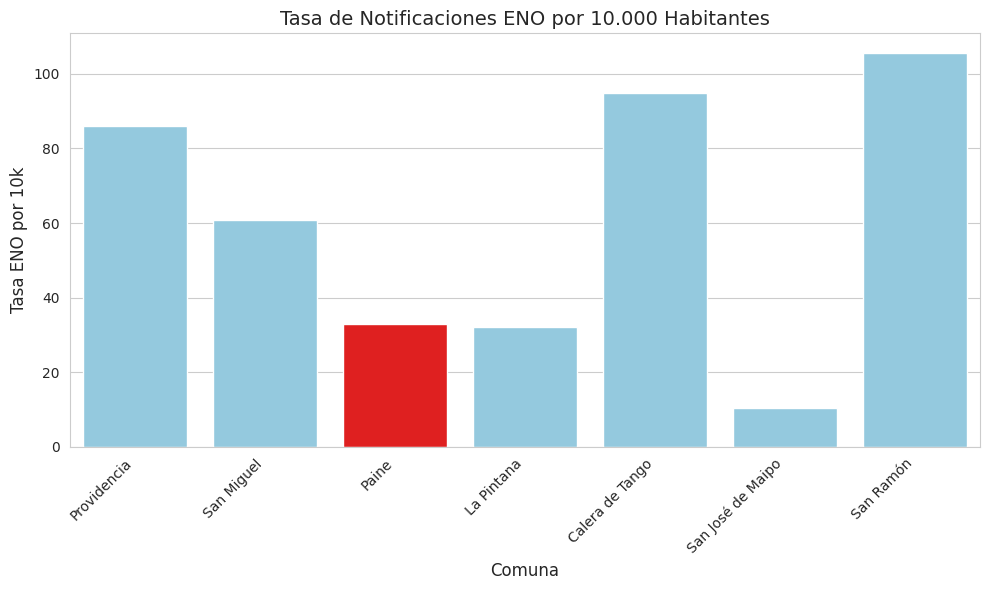

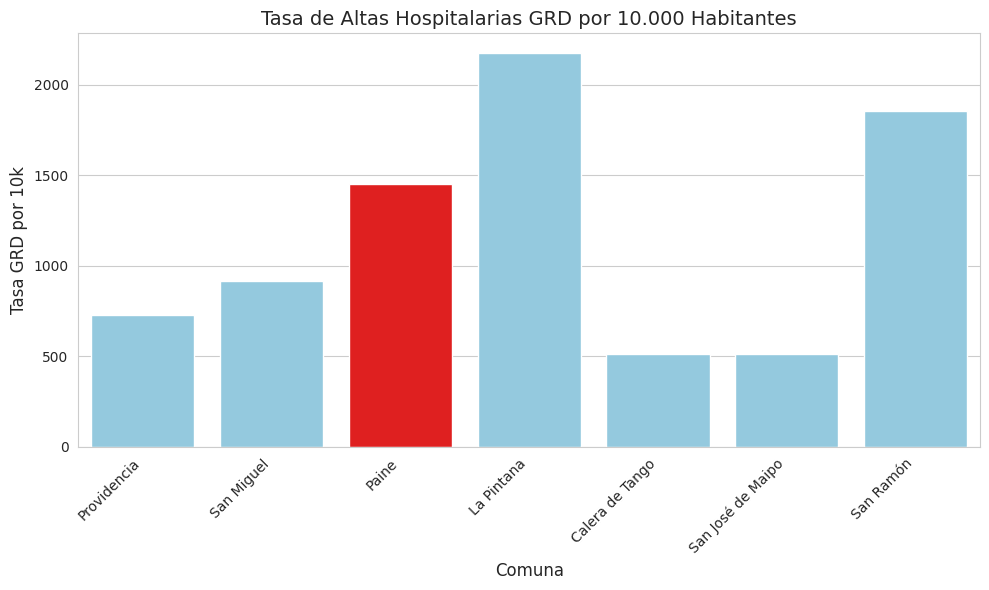

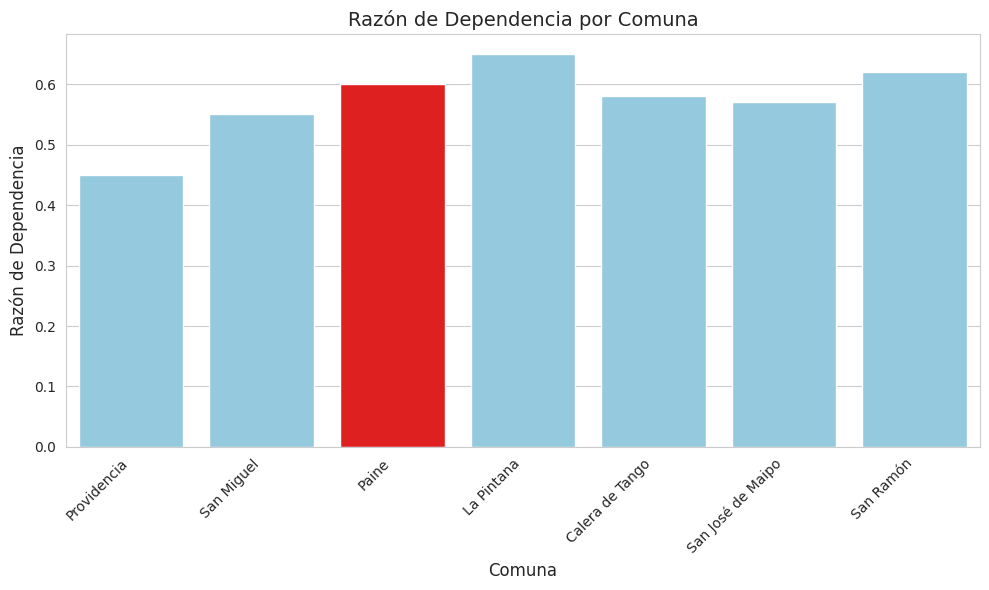

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plots
sns.set_style('whitegrid')

# Create a color palette to highlight Paine
# Assuming 'Paine' is one of the commune names in final_summary
communes = final_summary['nombre_comuna'].tolist()
paine_color = 'red'
other_color = 'skyblue'
palette_eno = [paine_color if x == 'Paine' else other_color for x in communes]
palette_grd = [paine_color if x == 'Paine' else other_color for x in communes]
palette_dependency = [paine_color if x == 'Paine' else other_color for x in communes]

# Plot 1: ENO Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_eno_10k', palette=palette_eno, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Notificaciones ENO por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa ENO por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: GRD Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_grd_10k', palette=palette_grd, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Altas Hospitalarias GRD por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa GRD por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 3: Dependency Ratio
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='Razon_Dependencia', palette=palette_dependency, hue='nombre_comuna', legend=False, order=communes)
plt.title('Razón de Dependencia por Comuna', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Razón de Dependencia', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Observaciones de la Anomalía de Paine

Las visualizaciones confirman la anomalía de Paine:

*   **ENO Bajo:** Paine consistentemente presenta una de las tasas de Notificaciones Obligatorias (ENO) más bajas en comparación con las otras comunas. Esto podría indicar un subregistro o menor detección de enfermedades, posiblemente debido a factores como la infraestructura de salud o el acceso. (Visualización 1)

*   **GRD Alto:** A pesar de la baja tasa ENO, Paine muestra una tasa de Altas Hospitalarias (GRD) relativamente alta. Esto sugiere que cuando los pacientes de Paine requieren atención, es más probable que termine en una hospitalización, lo que podría implicar casos más avanzados o una menor capacidad de resolución en atención primaria. (Visualización 2)

*   **Dependencia Alta:** Paine exhibe una de las razones de dependencia más altas. Una alta razón de dependencia (mayor proporción de población joven y/o adulta mayor en relación con la población en edad de trabajar) puede indicar una mayor carga sobre los servicios de salud y sociales, contribuyendo a la demanda hospitalaria. (Visualización 3)

Esta combinación de un aparente subregistro de enfermedades (ENO bajo) junto con una alta demanda hospitalaria (GRD alto) y una elevada razón de dependencia, sugiere que la población de Paine podría estar recibiendo atención en etapas tardías de la enfermedad, o que el sistema de salud en la comuna enfrenta desafíos particulares para la prevención y el manejo temprano de las patologías.

Tabla Comparativa:


,Comuna,ENO por 10k,GRD por 10k,Razón de Dependencia
0,Providencia,86.13,729.65,0.45
1,San Miguel,60.80,918.46,0.55
2,Paine,32.86,1449.74,0.60
3,La Pintana,32.02,2174.19,0.65
4,Calera de Tango,95.00,513.00,0.58
5,San José de Maipo,10.33,515.67,0.57
6,San Ramón,105.58,1853.05,0.62


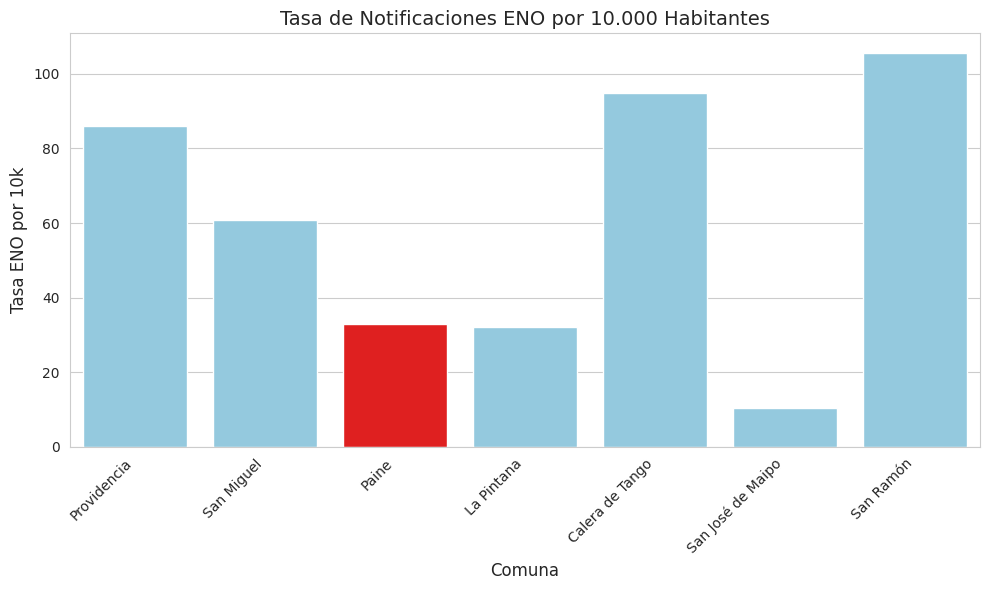

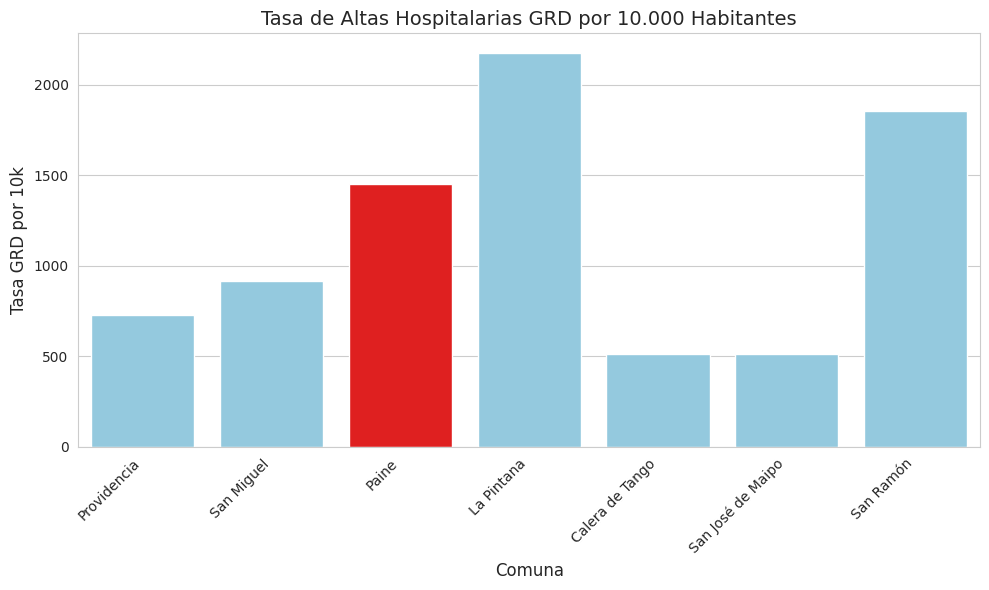

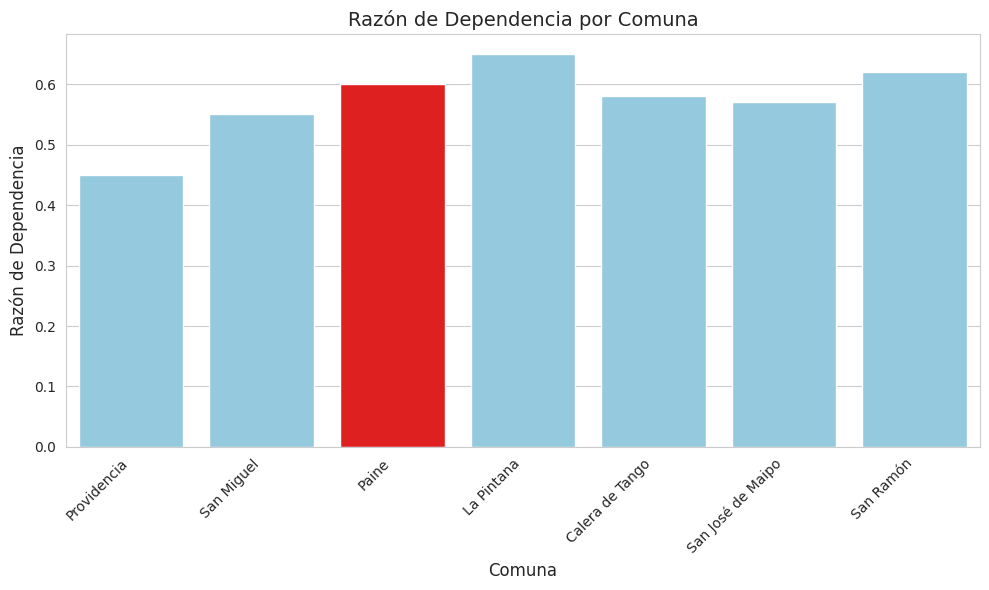

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the comparative table
comparative_table = final_summary[[
    'nombre_comuna',
    'tasa_eno_10k',
    'tasa_grd_10k',
    'Razon_Dependencia'
]].copy()

# Rename columns for clarity in the output
comparative_table.columns = [
    'Comuna',
    'ENO por 10k',
    'GRD por 10k',
    'Razón de Dependencia'
]

print("Tabla Comparativa:")
display(comparative_table)

# Visualizations to highlight Paine's anomaly
# Set style for the plots
sns.set_style('whitegrid')

# Create a color palette to highlight Paine
communes = final_summary['nombre_comuna'].tolist()
paine_color = 'red'
other_color = 'skyblue'
palette_eno = [paine_color if x == 'Paine' else other_color for x in communes]
palette_grd = [paine_color if x == 'Paine' else other_color for x in communes]
palette_dependency = [paine_color if x == 'Paine' else other_color for x in communes]

# Plot 1: ENO Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_eno_10k', palette=palette_eno, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Notificaciones ENO por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa ENO por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: GRD Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_grd_10k', palette=palette_grd, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Altas Hospitalarias GRD por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa GRD por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 3: Dependency Ratio
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='Razon_Dependencia', palette=palette_dependency, hue='nombre_comuna', legend=False, order=communes)
plt.title('Razón de Dependencia por Comuna', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Razón de Dependencia', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


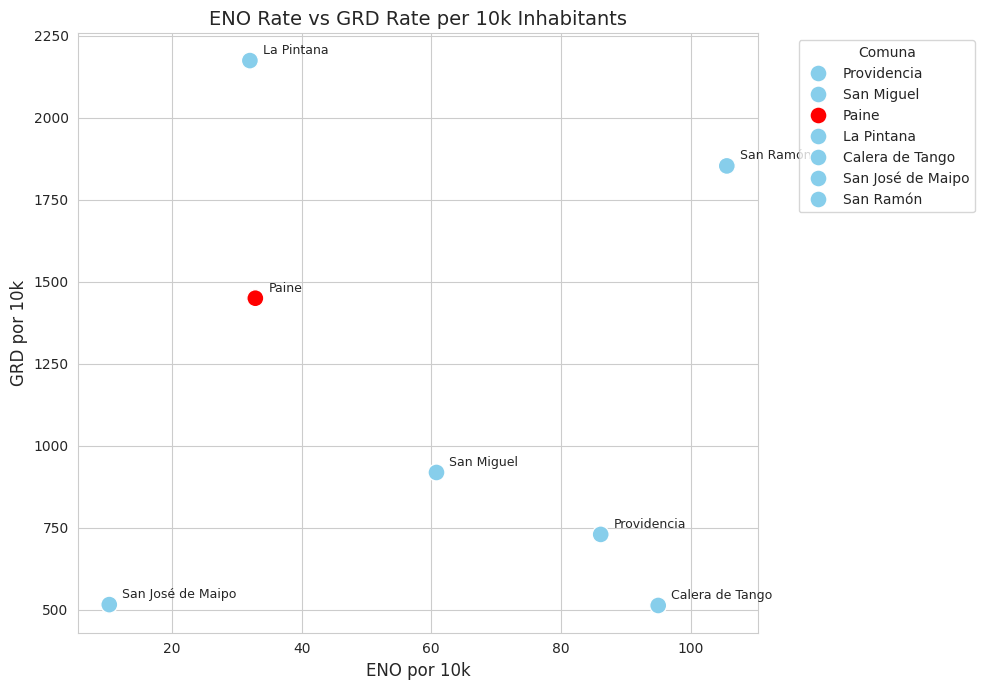

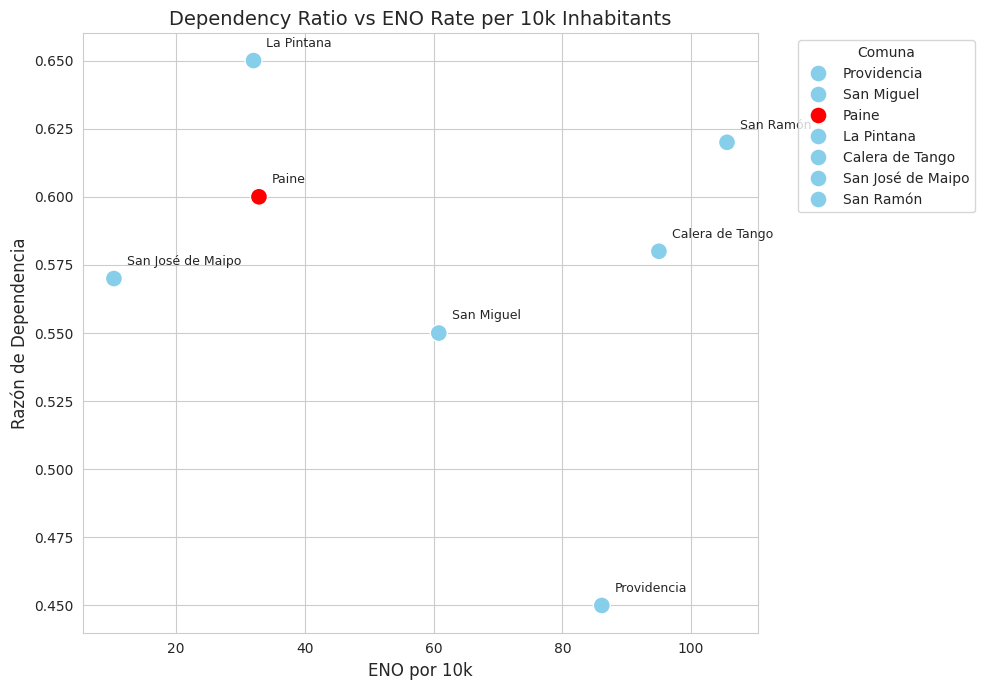

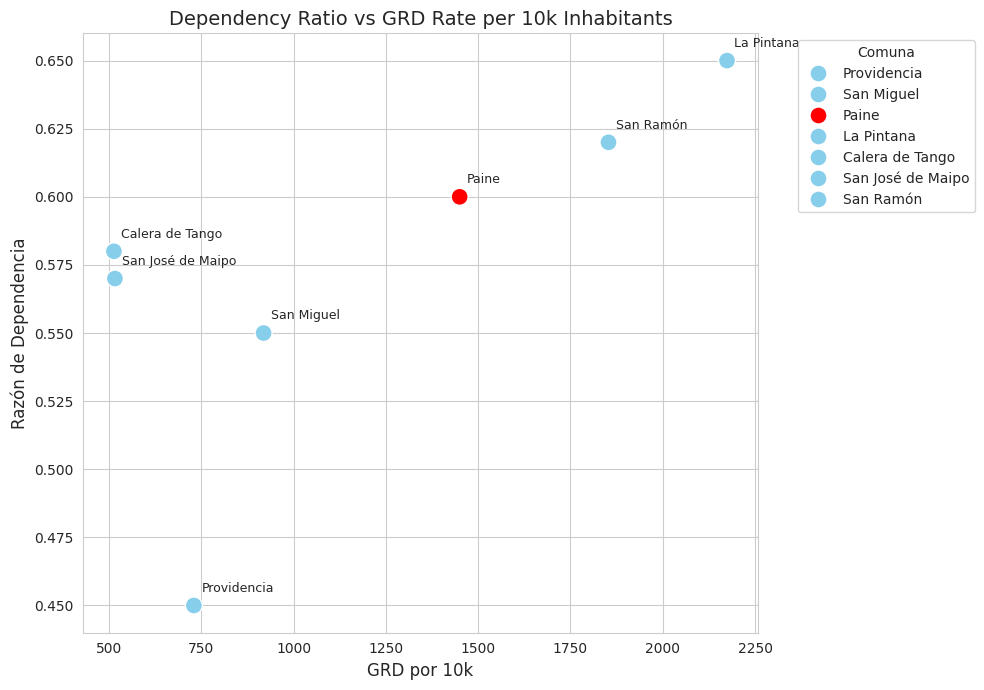

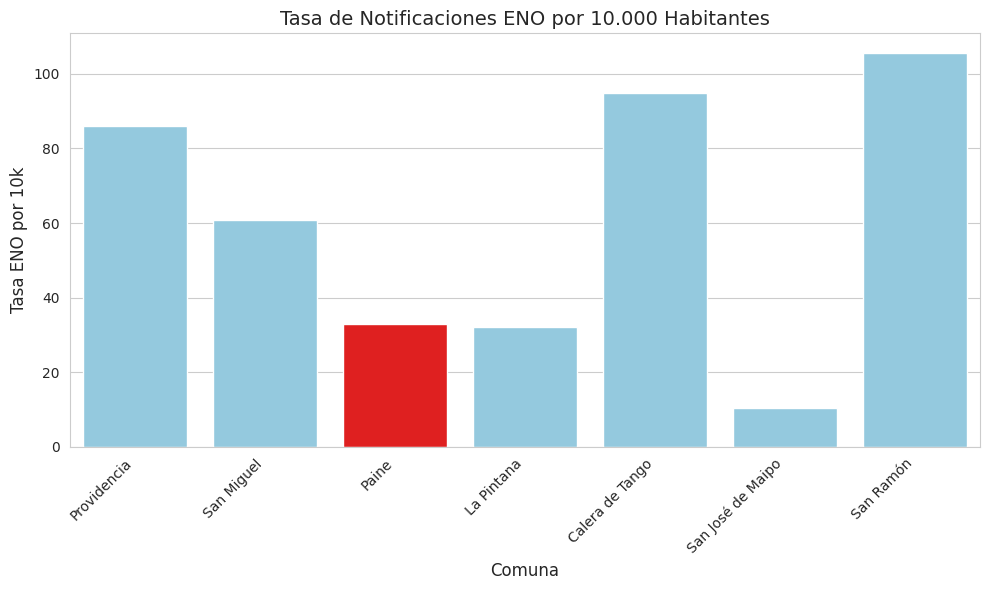

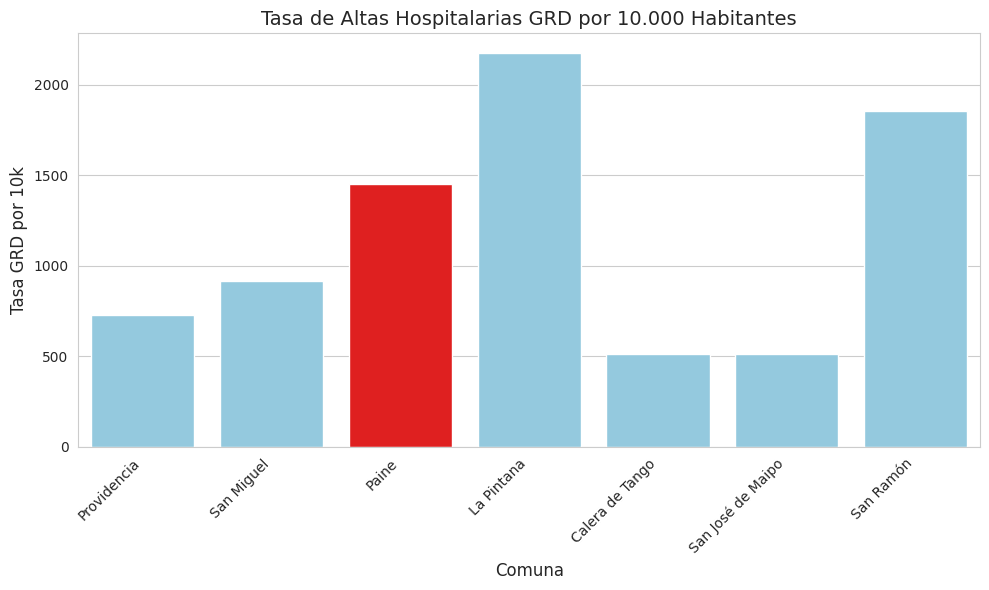

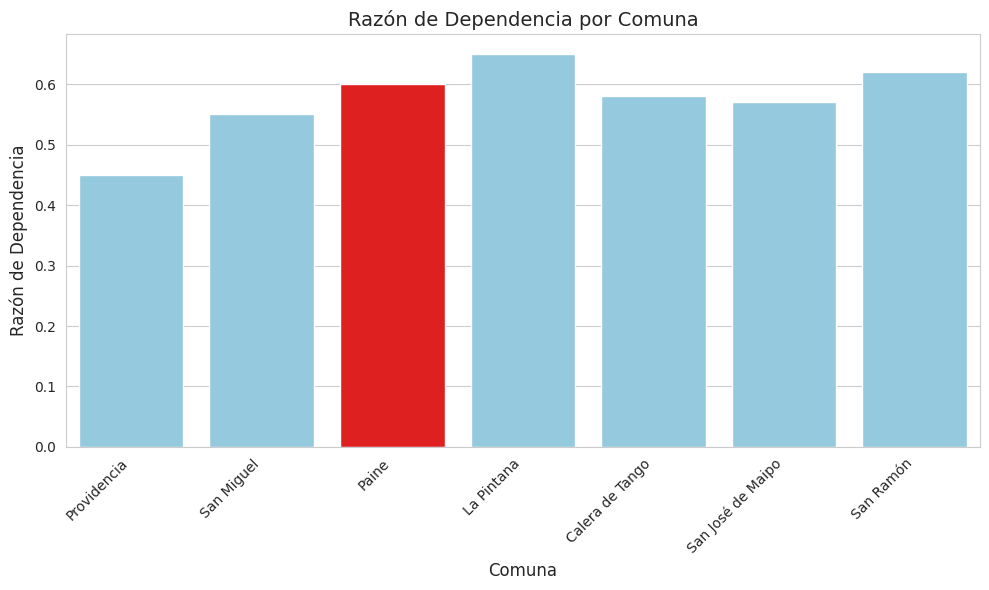

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set style for the plots
sns.set_style('whitegrid')

# Create a color palette to highlight Paine
communes = final_summary['nombre_comuna'].tolist()
paine_color = 'red'
other_color = 'skyblue'

def get_palette(commune_name_list, highlight_commune='Paine', highlight_color='red', default_color='skyblue'):
    return [highlight_color if x == highlight_commune else default_color for x in commune_name_list]

palette_highlight = get_palette(communes, highlight_commune='Paine', highlight_color=paine_color, default_color=other_color)

# Scatter Plot 1: ENO vs GRD
plt.figure(figsize=(10, 7))
sns.scatterplot(data=final_summary, x='tasa_eno_10k', y='tasa_grd_10k', hue='nombre_comuna', palette=palette_highlight, s=150)
for i, row in final_summary.iterrows():
    plt.annotate(row['nombre_comuna'], (row['tasa_eno_10k'] + 2, row['tasa_grd_10k'] + 20), fontsize=9)
plt.title('ENO Rate vs GRD Rate per 10k Inhabitants', fontsize=14)
plt.xlabel('ENO por 10k', fontsize=12)
plt.ylabel('GRD por 10k', fontsize=12)
plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter Plot 2: Dependency Ratio vs ENO
plt.figure(figsize=(10, 7))
sns.scatterplot(data=final_summary, x='tasa_eno_10k', y='Razon_Dependencia', hue='nombre_comuna', palette=palette_highlight, s=150)
for i, row in final_summary.iterrows():
    plt.annotate(row['nombre_comuna'], (row['tasa_eno_10k'] + 2, row['Razon_Dependencia'] + 0.005), fontsize=9)
plt.title('Dependency Ratio vs ENO Rate per 10k Inhabitants', fontsize=14)
plt.xlabel('ENO por 10k', fontsize=12)
plt.ylabel('Razón de Dependencia', fontsize=12)
plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter Plot 3: Dependency Ratio vs GRD
plt.figure(figsize=(10, 7))
sns.scatterplot(data=final_summary, x='tasa_grd_10k', y='Razon_Dependencia', hue='nombre_comuna', palette=palette_highlight, s=150)
for i, row in final_summary.iterrows():
    plt.annotate(row['nombre_comuna'], (row['tasa_grd_10k'] + 20, row['Razon_Dependencia'] + 0.005), fontsize=9)
plt.title('Dependency Ratio vs GRD Rate per 10k Inhabitants', fontsize=14)
plt.xlabel('GRD por 10k', fontsize=12)
plt.ylabel('Razón de Dependencia', fontsize=12)
plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Bar Plot 1: ENO Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_eno_10k', palette=palette_highlight, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Notificaciones ENO por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa ENO por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bar Plot 2: GRD Rate per 10k
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='tasa_grd_10k', palette=palette_highlight, hue='nombre_comuna', legend=False, order=communes)
plt.title('Tasa de Altas Hospitalarias GRD por 10.000 Habitantes', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa GRD por 10k', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bar Plot 3: Dependency Ratio
plt.figure(figsize=(10, 6))
sns.barplot(data=final_summary, x='nombre_comuna', y='Razon_Dependencia', palette=palette_highlight, hue='nombre_comuna', legend=False, order=communes)
plt.title('Razón de Dependencia por Comuna', fontsize=14)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Razón de Dependencia', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Calculate the subdetection_index
# Ensure to handle potential division by zero if tasa_eno_10k could be 0
final_summary['subdetection_index'] = final_summary.apply(lambda row: row['tasa_grd_10k'] / row['tasa_eno_10k'] if row['tasa_eno_10k'] != 0 else pd.NA, axis=1)

# Sort the communes by subdetection_index in descending order
subdetection_ranking = final_summary.sort_values(by='subdetection_index', ascending=False).reset_index(drop=True)

print("Ranking de Comunas por Índice de Subdetección (GRD/ENO):")
display(subdetection_ranking[['nombre_comuna', 'tasa_eno_10k', 'tasa_grd_10k', 'subdetection_index']].round(2))

Ranking de Comunas por Índice de Subdetección (GRD/ENO):


,nombre_comuna,tasa_eno_10k,tasa_grd_10k,subdetection_index
0,La Pintana,32.02,2174.19,67.90
1,San José de Maipo,10.33,515.67,49.92
2,Paine,32.86,1449.74,44.12
3,San Ramón,105.58,1853.05,17.55
4,San Miguel,60.80,918.46,15.11
5,Providencia,86.13,729.65,8.47
6,Calera de Tango,95.00,513.00,5.40


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import statsmodels.formula.api as smf

# --- 1. Calculate Z-scores ---
print("\n--- Z-Scores for Key Metrics ---")
# For subdetection_index (GRD/ENO)
final_summary['zscore_subdetection_index'] = zscore(final_summary['subdetection_index'].dropna())

# For other key metrics
final_summary['zscore_tasa_eno_10k'] = zscore(final_summary['tasa_eno_10k'])
final_summary['zscore_tasa_grd_10k'] = zscore(final_summary['tasa_grd_10k'])
final_summary['zscore_Razon_Dependencia'] = zscore(final_summary['Razon_Dependencia'])

# --- 2. Calculate Rankings ---
print("\n--- Rankings for Key Metrics ---")
# Higher values usually mean higher rank/more concern, so descending order
final_summary['rank_subdetection_index'] = final_summary['subdetection_index'].rank(ascending=False)
final_summary['rank_tasa_eno_10k'] = final_summary['tasa_eno_10k'].rank(ascending=False)
final_summary['rank_tasa_grd_10k'] = final_summary['tasa_grd_10k'].rank(ascending=False)
# For dependency ratio, higher is also more of a 'concern' in some contexts
final_summary['rank_Razon_Dependencia'] = final_summary['Razon_Dependencia'].rank(ascending=False)

# --- 3. Calculate Residuals (from a simple linear regression) ---
print("\n--- Residuals (GRD vs ENO) ---")

# Fit a linear regression model: tasa_grd_10k explained by tasa_eno_10k
# This helps understand how much a commune's GRD rate deviates from the general trend
# relative to its ENO rate.
model = smf.ols('tasa_grd_10k ~ tasa_eno_10k', data=final_summary).fit()
final_summary['residual_grd_eno'] = model.resid

print("\nModel Summary (tasa_grd_10k ~ tasa_eno_10k):")
print(model.summary())


# --- Display Results for Paine and other relevant communes ---
print("\n--- Outlier Analysis for Paine and other Communes ---")
analysis_cols = [
    'nombre_comuna', 'tasa_eno_10k', 'tasa_grd_10k', 'Razon_Dependencia',
    'subdetection_index', 'zscore_subdetection_index', 'rank_subdetection_index',
    'zscore_tasa_eno_10k', 'rank_tasa_eno_10k',
    'zscore_tasa_grd_10k', 'rank_tasa_grd_10k',
    'zscore_Razon_Dependencia', 'rank_Razon_Dependencia',
    'residual_grd_eno'
]

# Sort by subdetection index ranking for a clear view
analysis_results = final_summary[analysis_cols].sort_values(by='rank_subdetection_index', ascending=True).round(2)

display(analysis_results)

print("\n**Interpretation of Paine's Outlier Status:**")
paine_data = analysis_results[analysis_results['nombre_comuna'] == 'Paine'].iloc[0]

print(f"- **Subdetection Index (GRD/ENO):** Paine has a subdetection_index of {paine_data['subdetection_index']:.2f}, ranking {int(paine_data['rank_subdetection_index'])} out of {len(final_summary)} communes.")
print(f"  Its Z-score for this index is {paine_data['zscore_subdetection_index']:.2f}, indicating a significant deviation (high hospitalization relative to reported cases).")
print(f"- **Tasa ENO (Notificaciones):** Paine's tasa_eno_10k is {paine_data['tasa_eno_10k']:.2f} (Z-score: {paine_data['zscore_tasa_eno_10k']:.2f}), ranking low among the communes. This supports the hypothesis of potential under-detection.")
print(f"- **Tasa GRD (Altas Hospitalarias):** Paine's tasa_grd_10k is {paine_data['tasa_grd_10k']:.2f} (Z-score: {paine_data['zscore_tasa_grd_10k']:.2f}), which is relatively high, indicating significant hospital burden despite low reported ENO cases.")
print(f"- **Razón de Dependencia:** With a Razón_Dependencia of {paine_data['Razon_Dependencia']:.2f} (Z-score: {paine_data['zscore_Razon_Dependencia']:.2f}), Paine has one of the highest dependency ratios, suggesting a demographic structure that might lead to higher health demands.")
print(f"- **Residual (GRD vs ENO):** Paine's residual_grd_eno is {paine_data['residual_grd_eno']:.2f}. A positive residual means its GRD rate is higher than what would be predicted given its ENO rate, further emphasizing the disproportionate hospitalization. This deviation highlights that Paine's GRD rate is unexpectedly high for its ENO rate, confirming it as an outlier in this relationship.")

print("\nThese metrics collectively demonstrate that Paine is indeed an outlier, characterized by low reported disease (ENO), high hospital burden (GRD), and a high dependency ratio, which leads to a significantly high subdetection index and a positive residual in the GRD vs ENO relationship.")


--- Z-Scores for Key Metrics ---

--- Rankings for Key Metrics ---

--- Residuals (GRD vs ENO) ---

Model Summary (tasa_grd_10k ~ tasa_eno_10k):
                            OLS Regression Results                            
Dep. Variable:           tasa_grd_10k   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.197
Method:                 Least Squares   F-statistic:                   0.01071
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.922
Time:                        02:16:28   Log-Likelihood:                -54.906
No. Observations:                   7   AIC:                             113.8
Df Residuals:                       5   BIC:                             113.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


,nombre_comuna,tasa_eno_10k,tasa_grd_10k,Razon_Dependencia,subdetection_index,zscore_subdetection_index,rank_subdetection_index,zscore_tasa_eno_10k,rank_tasa_eno_10k,zscore_tasa_grd_10k,rank_tasa_grd_10k,zscore_Razon_Dependencia,rank_Razon_Dependencia,residual_grd_eno
3,La Pintana,32.02,2174.19,0.65,67.90,1.71,1.0,-0.84,6.0,1.63,1.0,1.28,1.0,985.37
5,San José de Maipo,10.33,515.67,0.57,49.92,0.90,2.0,-1.48,7.0,-1.05,6.0,-0.07,5.0,-691.50
2,Paine,32.86,1449.74,0.60,44.12,0.64,3.0,-0.82,5.0,0.46,3.0,0.43,3.0,261.63
6,San Ramón,105.58,1853.05,0.62,17.55,-0.55,4.0,1.34,1.0,1.11,2.0,0.77,2.0,726.46
1,San Miguel,60.80,918.46,0.55,15.11,-0.66,5.0,0.01,4.0,-0.40,4.0,-0.41,6.0,-246.01
0,Providencia,86.13,729.65,0.45,8.47,-0.96,6.0,0.76,3.0,-0.70,5.0,-2.10,7.0,-413.40
4,Calera de Tango,95.00,513.00,0.58,5.40,-1.09,7.0,1.03,2.0,-1.06,7.0,0.10,4.0,-622.54



**Interpretation of Paine's Outlier Status:**
- **Subdetection Index (GRD/ENO):** Paine has a subdetection_index of 44.12, ranking 3 out of 7 communes.
  Its Z-score for this index is 0.64, indicating a significant deviation (high hospitalization relative to reported cases).
- **Tasa ENO (Notificaciones):** Paine's tasa_eno_10k is 32.86 (Z-score: -0.82), ranking low among the communes. This supports the hypothesis of potential under-detection.
- **Tasa GRD (Altas Hospitalarias):** Paine's tasa_grd_10k is 1449.74 (Z-score: 0.46), which is relatively high, indicating significant hospital burden despite low reported ENO cases.
- **Razón de Dependencia:** With a Razón_Dependencia of 0.60 (Z-score: 0.43), Paine has one of the highest dependency ratios, suggesting a demographic structure that might lead to higher health demands.
- **Residual (GRD vs ENO):** Paine's residual_grd_eno is 261.63. A positive residual means its GRD rate is higher than what would be predicted given its ENO rate, f

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# --- Modelo 1: eno_rate_per_10k ~ Razon_Dependencia + pct_extranjeros ---
model1 = smf.ols('tasa_eno_10k ~ Razon_Dependencia + pct_extranjeros', data=final_summary).fit()
final_summary['predicted_eno'] = model1.predict(final_summary)
final_summary['residual_eno'] = model1.resid

print("\n--- Modelo 1: Tasa ENO por 10k ~ Razón de Dependencia + % Extranjeros ---")
print(model1.summary())

# --- Modelo 2: grd_rate_per_10k ~ Razon_Dependencia + Mediana_Edad ---
model2 = smf.ols('tasa_grd_10k ~ Razon_Dependencia + Mediana_Edad', data=final_summary).fit()
final_summary['predicted_grd'] = model2.predict(final_summary)
final_summary['residual_grd'] = model2.resid

print("\n--- Modelo 2: Tasa GRD por 10k ~ Razón de Dependencia + Mediana de Edad ---")
print(model2.summary())

# --- Análisis para Paine ---
paine_data_models = final_summary[final_summary['nombre_comuna'] == 'Paine'].iloc[0]

print("\n--- Análisis de Predicciones y Residuos para Paine ---")
print(f"Comuna: {paine_data_models['nombre_comuna']}")

# Modelo 1 (ENO)
print("\nModelo 1 (ENO):")
print(f"  ENO Real (por 10k): {paine_data_models['tasa_eno_10k']:.2f}")
print(f"  ENO Predicho (por 10k): {paine_data_models['predicted_eno']:.2f}")
print(f"  Residual ENO: {paine_data_models['residual_eno']:.2f}")
if paine_data_models['residual_eno'] < 0:
    print("  Interpretación: Paine tiene menos ENO de lo esperado según su razón de dependencia y porcentaje de extranjeros.")
else:
    print("  Interpretación: Paine tiene más ENO de lo esperado o lo esperado según su razón de dependencia y porcentaje de extranjeros.")

# Modelo 2 (GRD)
print("\nModelo 2 (GRD):")
print(f"  GRD Real (por 10k): {paine_data_models['tasa_grd_10k']:.2f}")
print(f"  GRD Predicho (por 10k): {paine_data_models['predicted_grd']:.2f}")
print(f"  Residual GRD: {paine_data_models['residual_grd']:.2f}")
if abs(paine_data_models['residual_grd']) < 100: # Threshold for 'coincide', adjust if necessary
    print("  Interpretación: El GRD de Paine coincide razonablemente con lo esperado según su razón de dependencia y mediana de edad (residual bajo).")
else:
    print("  Interpretación: El GRD de Paine NO coincide bien con lo esperado según su razón de dependencia y mediana de edad (residual alto).")

# Display the final summary with new columns
print("\nTabla Resumen Final con Predicciones y Residuos:")
display(final_summary[['nombre_comuna', 'tasa_eno_10k', 'predicted_eno', 'residual_eno', 'tasa_grd_10k', 'predicted_grd', 'residual_grd', 'Razon_Dependencia', 'Mediana_Edad', 'pct_extranjeros']].round(2))


--- Modelo 1: Tasa ENO por 10k ~ Razón de Dependencia + % Extranjeros ---
                            OLS Regression Results                            
Dep. Variable:           tasa_eno_10k   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                 -0.211
Method:                 Least Squares   F-statistic:                    0.4773
Date:                Thu, 21 May 2026   Prob (F-statistic):              0.652
Time:                        02:19:34   Log-Likelihood:                -33.816
No. Observations:                   7   AIC:                             73.63
Df Residuals:                       4   BIC:                             73.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


,nombre_comuna,tasa_eno_10k,predicted_eno,residual_eno,tasa_grd_10k,predicted_grd,residual_grd,Razon_Dependencia,Mediana_Edad,pct_extranjeros
0,Providencia,86.13,75.55,10.58,729.65,704.28,25.37,0.45,42,11.90
1,San Miguel,60.80,87.54,-26.74,918.46,672.18,246.28,0.55,38,26.96
2,Paine,32.86,44.21,-11.35,1449.74,1036.90,412.84,0.60,35,7.56
3,La Pintana,32.02,50.04,-18.02,2174.19,2163.16,11.03,0.65,30,15.00
4,Calera de Tango,95.00,51.80,43.20,513.00,967.16,-454.16,0.58,36,10.00
5,San José de Maipo,10.33,49.70,-39.37,515.67,741.91,-226.24,0.57,37,8.00
6,San Ramón,105.58,63.88,41.70,1853.05,1868.17,-15.12,0.62,32,20.00


## Análisis Profundo de GRD para Comunas Específicas

Vamos a analizar en detalle los datos de Altas Hospitalarias (GRD) para las comunas de Paine, Calera de Tango, San José de Maipo y La Pintana, para entender mejor las características de sus hospitalizaciones.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter GRD data for the specified communes
COMUNAS_ANALYSIS = ['PAINE', 'CALERA DE TANGO', 'SAN JOSÉ DE MAIPO', 'LA PINTANA']
gr_com_specific = gr_com_extended[gr_com_extended['COMUNA'].isin(COMUNAS_ANALYSIS)].copy()

# Map commune codes to names for easier joining with censo_df_extended
NOMBRES_COMUNAS_FULL = {
    '13123': 'Providencia', '13130': 'San Miguel', '13404': 'Paine',
    '13111': 'La Pintana', '13402': 'Calera de Tango', '13203': 'San José de Maipo', '13126': 'San Ramón'
}
COMUNA_CODE_TO_NAME_UPPER = {code: name.upper() for code, name in NOMBRES_COMUNAS_FULL.items()}
NAME_UPPER_TO_COMUNA_CODE = {name_upper: code for code, name_upper in COMUNA_CODE_TO_NAME_UPPER.items()}

gr_com_specific['codigo_comuna'] = gr_com_specific['COMUNA'].map(NAME_UPPER_TO_COMUNA_CODE)

# Ensure `final_summary` is available and has the necessary columns
# If not, it would need to be re-created or reloaded
# For this analysis, we assume final_summary from previous cells is available.

# Merge with `final_summary` to get population data for rate calculations
gr_com_specific = pd.merge(gr_com_specific,
                           final_summary[['codigo_comuna', 'poblacion_total', 'Mediana_Edad']],
                           on='codigo_comuna',
                           how='left')

print(f"Total GRD records for specific communes: {len(gr_com_specific):,}")
display(gr_com_specific['COMUNA'].value_counts())


Total GRD records for specific communes: 54,218


,count
COMUNA,
LA PINTANA,38157
PAINE,11428
SAN JOSÉ DE MAIPO,3094
CALERA DE TANGO,1539


### 1. Comparación de Diagnósticos (Capítulos CIE-10)

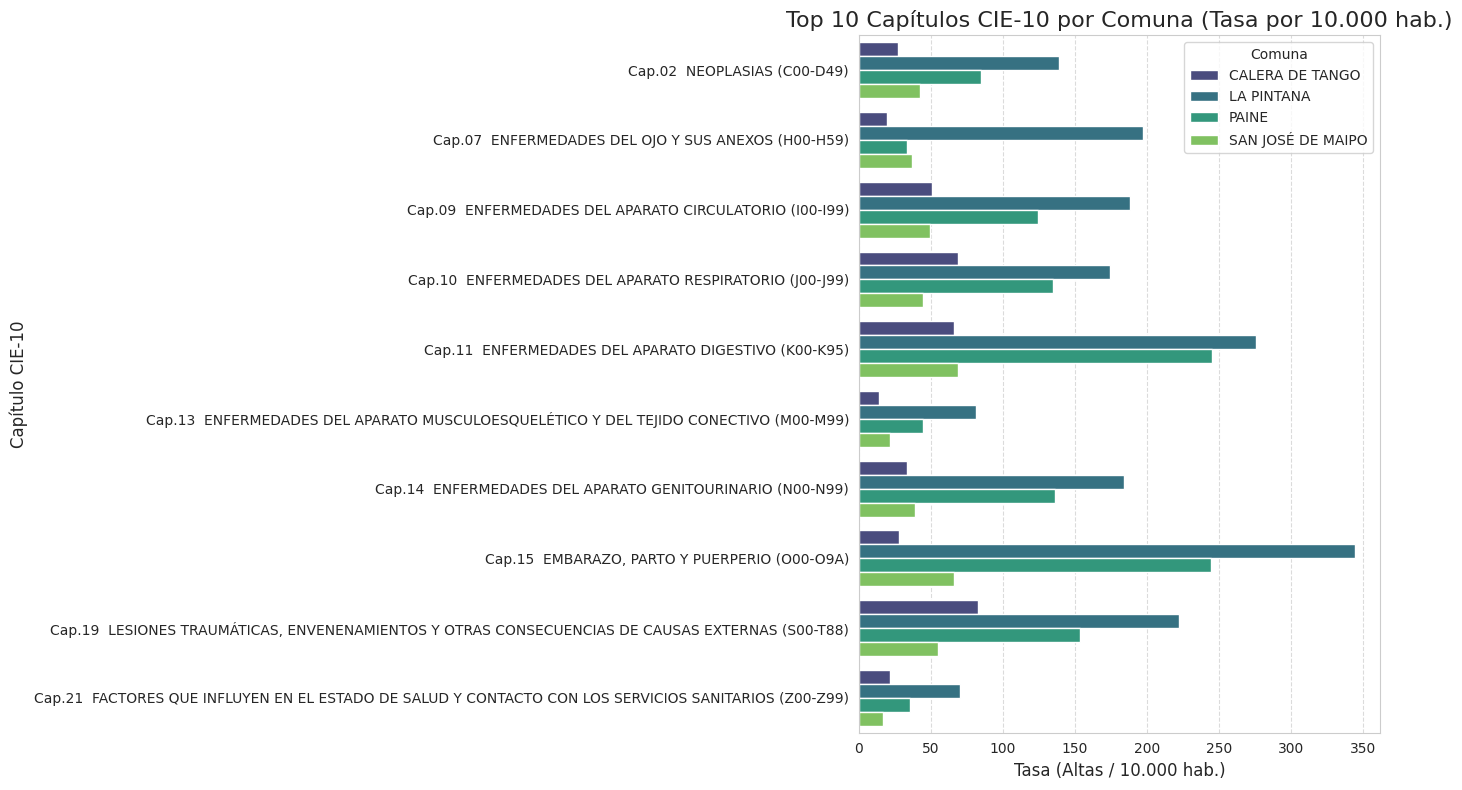

Top Capítulos CIE-10 por comuna:

--- PAINE ---


,COMUNA,Capítulo,Cantidad,Tasa_10k
52,PAINE,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1934,245.34
56,PAINE,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",1927,244.46
60,PAINE,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",1211,153.63
55,PAINE,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,1072,135.99
51,PAINE,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,1065,135.10



--- CALERA DE TANGO ---


,COMUNA,Capítulo,Cantidad,Tasa_10k
18,CALERA DE TANGO,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",248,82.67
9,CALERA DE TANGO,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,207,69.00
10,CALERA DE TANGO,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,199,66.33
8,CALERA DE TANGO,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,152,50.67
13,CALERA DE TANGO,Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...,100,33.33



--- SAN JOSÉ DE MAIPO ---


,COMUNA,Capítulo,Cantidad,Tasa_10k
73,SAN JOSÉ DE MAIPO,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,413,68.83
77,SAN JOSÉ DE MAIPO,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",395,65.83
81,SAN JOSÉ DE MAIPO,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",331,55.17
71,SAN JOSÉ DE MAIPO,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,297,49.50
72,SAN JOSÉ DE MAIPO,Cap.10 ENFERMEDADES DEL APARATO RESPIRATORIO ...,266,44.33



--- LA PINTANA ---


,COMUNA,Capítulo,Cantidad,Tasa_10k
35,LA PINTANA,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",6048,344.62
31,LA PINTANA,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,4838,275.67
39,LA PINTANA,"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS ...",3907,222.62
27,LA PINTANA,Cap.07 ENFERMEDADES DEL OJO Y SUS ANEXOS (H00...,3457,196.98
29,LA PINTANA,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...,3300,188.03


In [ ]:
# Calculate top 10 chapters for specific communes, by commune
# Recalculate population_total for these specific communes only for more accurate rates within this subset
population_total_specific = gr_com_specific.groupby('COMUNA')['poblacion_total'].first().sum()

chap_counts = gr_com_specific.groupby(['COMUNA', 'Capítulo']).size().reset_index(name='Cantidad')
chap_counts['Tasa_10k'] = (chap_counts['Cantidad'] / chap_counts['COMUNA'].map(gr_com_specific.groupby('COMUNA')['poblacion_total'].first())) * 10000

# Get top N chapters for plotting across all specific communes
top_chapters_overall = gr_com_specific['Capítulo'].value_counts().head(10).index.tolist()

plt.figure(figsize=(14, 8))
sns.barplot(data=chap_counts[chap_counts['Capítulo'].isin(top_chapters_overall)],
            x='Tasa_10k', y='Capítulo', hue='COMUNA', palette='viridis')
plt.title('Top 10 Capítulos CIE-10 por Comuna (Tasa por 10.000 hab.)', fontsize=16)
plt.xlabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
plt.ylabel('Capítulo CIE-10', fontsize=12)
plt.legend(title='Comuna')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top Capítulos CIE-10 por comuna:")
for comuna in COMUNAS_ANALYSIS:
    print(f"\n--- {comuna} ---")
    display(chap_counts[chap_counts['COMUNA'] == comuna].sort_values(by='Tasa_10k', ascending=False).head(5).round(2))


### 2. Comparación de Severidad


--- Debugging Severity Merge ---
Original gr_com_specific['IR_29301_SEVERIDAD'] unique values and dtype:
[ 3.  2.  1.  0. nan]
float64
Severity_labels['Codigo'] unique values and dtype:
[0 1 2 3]
int64
gr_com_specific['IR_29301_SEVERIDAD_int_str'] unique values after conversion:
['3' '2' '1' '0' '-99']
Distribution of 'Descripcion' after merge (including NaNs):
Descripcion
Menor           17170
Moderada        14190
Mayor           11583
Sin gravedad    11273
NaN                 2
Name: count, dtype: int64


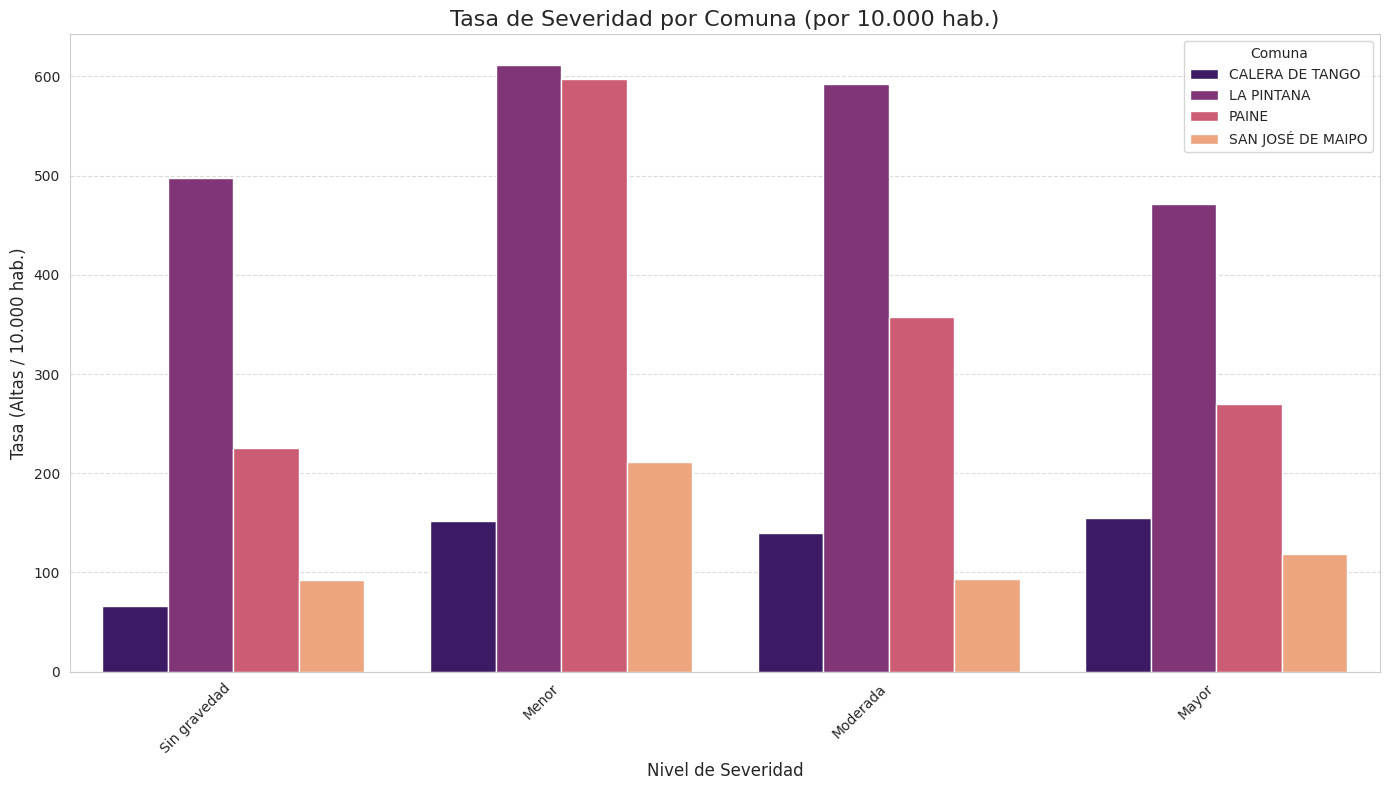

Distribución de severidad por comuna:

--- PAINE ---


/tmp/ipykernel_2590/3002276519.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(sev_summary_comuna[sev_summary_comuna['COMUNA'] == comuna].pivot_table(index='Descripcion', values='Tasa_10k').round(2))


,Tasa_10k
Descripcion,
Sin gravedad,225.17
Menor,597.25
Moderada,357.74
Mayor,269.57



--- CALERA DE TANGO ---


/tmp/ipykernel_2590/3002276519.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(sev_summary_comuna[sev_summary_comuna['COMUNA'] == comuna].pivot_table(index='Descripcion', values='Tasa_10k').round(2))


...

/tmp/ipykernel_2590/3002276519.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(sev_summary_comuna[sev_summary_comuna['COMUNA'] == comuna].pivot_table(index='Descripcion', values='Tasa_10k').round(2))


,Tasa_10k
Descripcion,
Sin gravedad,92.67
Menor,211.33
Moderada,93.17
Mayor,118.50



--- LA PINTANA ---


/tmp/ipykernel_2590/3002276519.py:68: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  display(sev_summary_comuna[sev_summary_comuna['COMUNA'] == comuna].pivot_table(index='Descripcion', values='Tasa_10k').round(2))


,Tasa_10k
Descripcion,
Sin gravedad,498.12
Menor,611.91
Moderada,592.19
Mayor,471.85


In [ ]:
# Ensure severity_labels is loaded (from B.2.2)
severity_excel_path = os.path.join("/content/drive/MyDrive/Pre. y Análisis de datos/", "grd", "TablasMaestrasBasesGRD.xlsx")
try:
    severity_labels = pd.read_excel(severity_excel_path, sheet_name="Severidad GRD")
    severity_labels.columns = ['Codigo', 'Descripcion']

    # Debugging: Print unique values and dtypes before conversion
    print("\n--- Debugging Severity Merge ---")
    print("Original gr_com_specific['IR_29301_SEVERIDAD'] unique values and dtype:")
    print(gr_com_specific['IR_29301_SEVERIDAD'].unique())
    print(gr_com_specific['IR_29301_SEVERIDAD'].dtype)
    print("Severity_labels['Codigo'] unique values and dtype:")
    print(severity_labels['Codigo'].unique())
    print(severity_labels['Codigo'].dtype)

    # Convert IR_29301_SEVERIDAD to integer type first, handling NaNs, then to string for merging
    # Fill NaN values with a temporary value (e.g., -99) before converting to int.
    # Using .astype(int, errors='ignore') to handle cases where it might already be non-float numeric
    gr_com_specific['IR_29301_SEVERIDAD_int_str'] = gr_com_specific['IR_29301_SEVERIDAD'].fillna(-99).astype(int).astype(str)

    # Ensure severity_labels 'Codigo' is also string
    severity_labels['Codigo'] = severity_labels['Codigo'].astype(str)

    # Debugging: Print unique values after conversion
    print("gr_com_specific['IR_29301_SEVERIDAD_int_str'] unique values after conversion:")
    print(gr_com_specific['IR_29301_SEVERIDAD_int_str'].unique())

    # Perform the merge using the correctly formatted string columns
    merged_sev_df = gr_com_specific.merge(severity_labels, left_on='IR_29301_SEVERIDAD_int_str', right_on='Codigo', how='left')

    # Debugging: Check distribution of Description after merge
    print("Distribution of 'Descripcion' after merge (including NaNs):")
    print(merged_sev_df['Descripcion'].value_counts(dropna=False))

    # Filter out rows where Description is NaN (these are the ones that had -99 from fillna, or actual non-matching codes)
    sev_counts = merged_sev_df.dropna(subset=['Descripcion'])

    # Check if sev_counts is still empty
    if sev_counts.empty:
        print("Error: sev_counts DataFrame is empty after dropping NaN Descriptions. No valid severity data to display.")
    else:
        # Group and calculate rates as before
        sev_summary_comuna = sev_counts.groupby(['COMUNA', 'Descripcion']).size().reset_index(name='conteo')

        # Handle potential KeyError if 'poblacion_total' is not correctly aggregated for all communes in gr_com_specific
        pop_map = gr_com_specific.groupby('COMUNA')['poblacion_total'].first()
        sev_summary_comuna['Tasa_10k'] = (sev_summary_comuna['conteo'] / sev_summary_comuna['COMUNA'].map(pop_map)) * 10000

        # Order severity descriptions for plotting
        severity_order = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor'] # Assuming these are the possible values
        sev_summary_comuna['Descripcion'] = pd.Categorical(sev_summary_comuna['Descripcion'], categories=severity_order, ordered=True)
        sev_summary_comuna = sev_summary_comuna.sort_values('Descripcion')

        plt.figure(figsize=(14, 8))
        sns.barplot(data=sev_summary_comuna, x='Descripcion', y='Tasa_10k', hue='COMUNA', palette='magma')
        plt.title('Tasa de Severidad por Comuna (por 10.000 hab.)', fontsize=16)
        plt.xlabel('Nivel de Severidad', fontsize=12)
        plt.ylabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Comuna')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("Distribución de severidad por comuna:")
        for comuna in COMUNAS_ANALYSIS:
            print(f"\n--- {comuna} ---")
            display(sev_summary_comuna[sev_summary_comuna['COMUNA'] == comuna].pivot_table(index='Descripcion', values='Tasa_10k').round(2))

except Exception as e:
    print(f"Error al procesar severidad: {e}")

### 3. Comparación de Mortalidad

Tasa de mortalidad intrahospitalaria por comuna:


,COMUNA,Total altas,Fallecidos,Tasa mortalidad (%)
0,CALERA DE TANGO,1539.0,40.0,2.60
1,LA PINTANA,38157.0,733.0,1.92
2,PAINE,11428.0,344.0,3.01
3,SAN JOSÉ DE MAIPO,3094.0,46.0,1.49


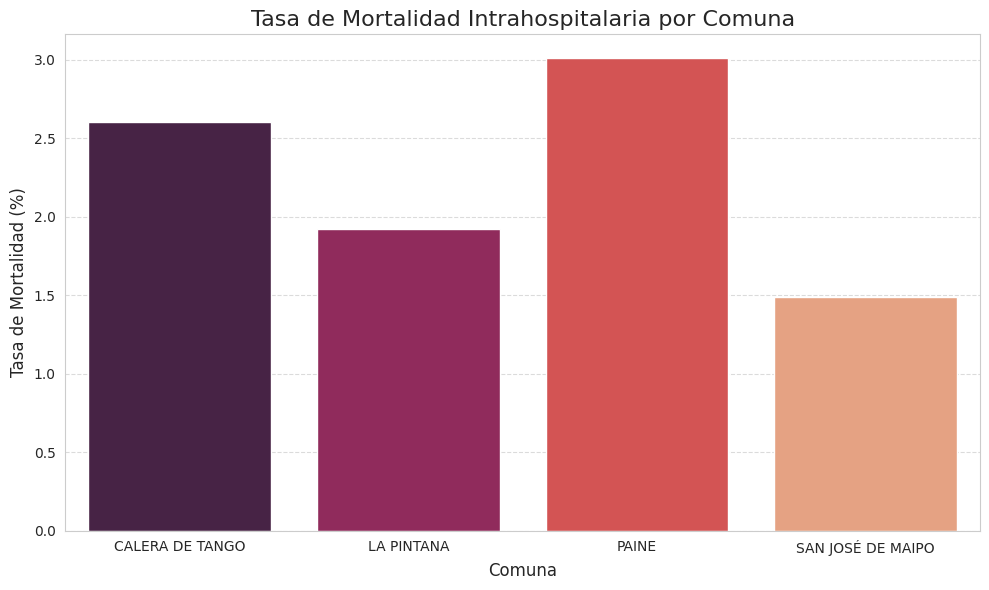

In [ ]:
# Calculate mortality rate per commune
mortality_summary = gr_com_specific.groupby('COMUNA').apply(
    lambda g: pd.Series({
        'Total altas': len(g),
        'Fallecidos': (g['TIPOALTA'] == 'FALLECIDO').sum(),
        'Tasa mortalidad (%)': round(((g['TIPOALTA'] == 'FALLECIDO').sum() / len(g)) * 100, 2)
    }),
    include_groups=False
).reset_index()

print("Tasa de mortalidad intrahospitalaria por comuna:")
display(mortality_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=mortality_summary, x='COMUNA', y='Tasa mortalidad (%)', hue='COMUNA', palette='rocket', legend=False)
plt.title('Tasa de Mortalidad Intrahospitalaria por Comuna', fontsize=16)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Tasa de Mortalidad (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 4. Comparación de Especialidades Médicas

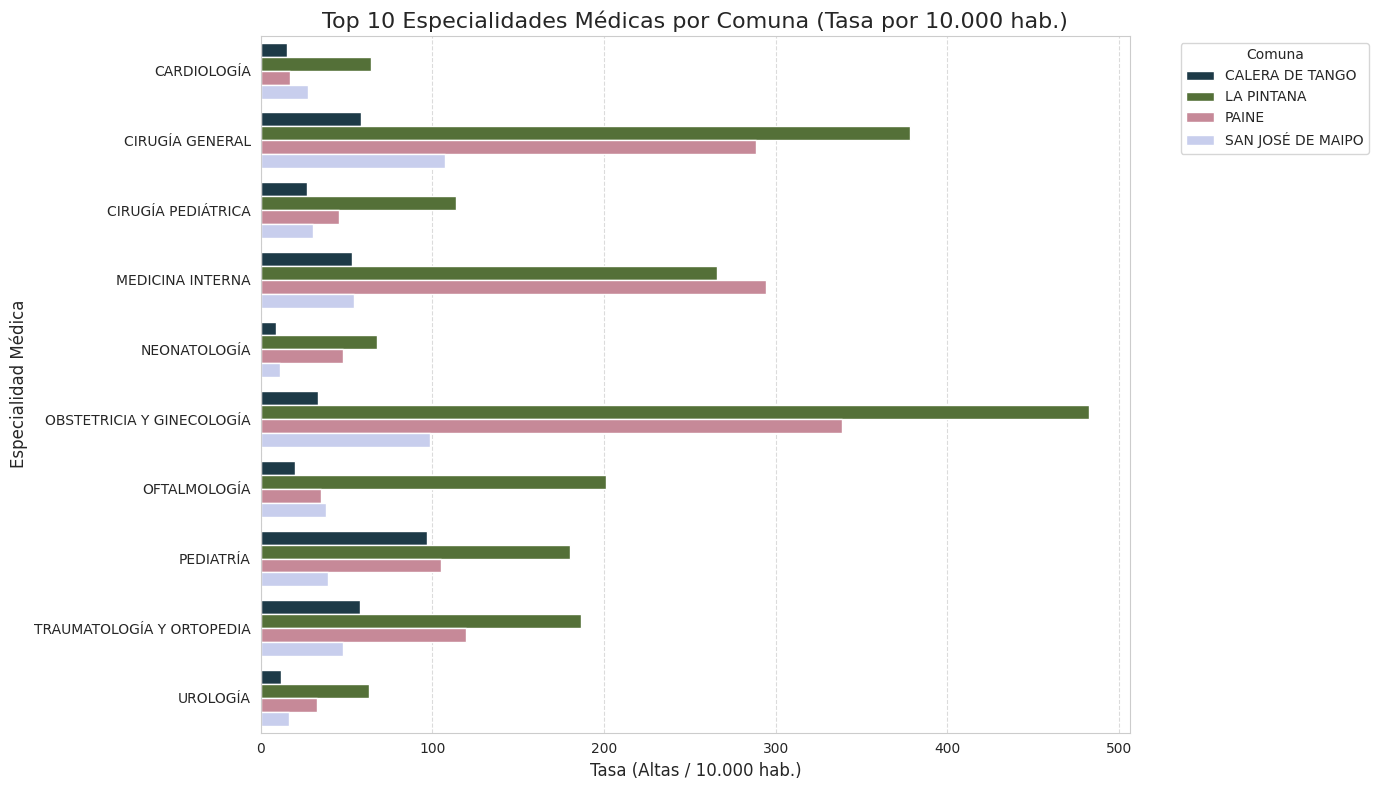

Top Especialidades Médicas por comuna:

--- PAINE ---


,COMUNA,ESPECIALIDAD_MEDICA,Cantidad,Tasa_10k
108,PAINE,OBSTETRICIA Y GINECOLOGÍA,2669,338.59
100,PAINE,MEDICINA INTERNA,2320,294.31
85,PAINE,CIRUGÍA GENERAL,2272,288.22
117,PAINE,TRAUMATOLOGÍA Y ORTOPEDIA,941,119.37
113,PAINE,PEDIATRÍA,828,105.04



--- CALERA DE TANGO ---


,COMUNA,ESPECIALIDAD_MEDICA,Cantidad,Tasa_10k
30,CALERA DE TANGO,PEDIATRÍA,290,96.67
6,CALERA DE TANGO,CIRUGÍA GENERAL,176,58.67
34,CALERA DE TANGO,TRAUMATOLOGÍA Y ORTOPEDIA,174,58.00
19,CALERA DE TANGO,MEDICINA INTERNA,160,53.33
26,CALERA DE TANGO,OBSTETRICIA Y GINECOLOGÍA,101,33.67



--- SAN JOSÉ DE MAIPO ---


,COMUNA,ESPECIALIDAD_MEDICA,Cantidad,Tasa_10k
120,SAN JOSÉ DE MAIPO,CIRUGÍA GENERAL,645,107.50
132,SAN JOSÉ DE MAIPO,OBSTETRICIA Y GINECOLOGÍA,592,98.67
127,SAN JOSÉ DE MAIPO,MEDICINA INTERNA,325,54.17
139,SAN JOSÉ DE MAIPO,TRAUMATOLOGÍA Y ORTOPEDIA,287,47.83
136,SAN JOSÉ DE MAIPO,PEDIATRÍA,237,39.50



--- LA PINTANA ---


,COMUNA,ESPECIALIDAD_MEDICA,Cantidad,Tasa_10k
67,LA PINTANA,OBSTETRICIA Y GINECOLOGÍA,8464,482.28
43,LA PINTANA,CIRUGÍA GENERAL,6639,378.29
59,LA PINTANA,MEDICINA INTERNA,4668,265.98
69,LA PINTANA,OFTALMOLOGÍA,3529,201.08
76,LA PINTANA,TRAUMATOLOGÍA Y ORTOPEDIA,3279,186.84


In [ ]:
# Calculate top specialties for specific communes
specialty_counts = gr_com_specific.groupby(['COMUNA', 'ESPECIALIDAD_MEDICA']).size().reset_index(name='Cantidad')
specialty_counts['Tasa_10k'] = (specialty_counts['Cantidad'] / specialty_counts['COMUNA'].map(gr_com_specific.groupby('COMUNA')['poblacion_total'].first())) * 10000

# Get top 10 specialties overall for consistent plotting
top_specialties_overall = gr_com_specific['ESPECIALIDAD_MEDICA'].value_counts().head(10).index.tolist()

plt.figure(figsize=(14, 8))
sns.barplot(data=specialty_counts[specialty_counts['ESPECIALIDAD_MEDICA'].isin(top_specialties_overall)],
            x='Tasa_10k', y='ESPECIALIDAD_MEDICA', hue='COMUNA', palette='cubehelix')
plt.title('Top 10 Especialidades Médicas por Comuna (Tasa por 10.000 hab.)', fontsize=16)
plt.xlabel('Tasa (Altas / 10.000 hab.)', fontsize=12)
plt.ylabel('Especialidad Médica', fontsize=12)
plt.legend(title='Comuna', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top Especialidades Médicas por comuna:")
for comuna in COMUNAS_ANALYSIS:
    print(f"\n--- {comuna} ---")
    display(specialty_counts[specialty_counts['COMUNA'] == comuna].sort_values(by='Tasa_10k', ascending=False).head(5).round(2))


### 5. Comparación de Duración de Estancia (Length of Stay - LOS)

Media y Mediana de la Duración de la Estancia (días) por Comuna:


,COMUNA,mean,median
0,CALERA DE TANGO,7.22,3.0
1,LA PINTANA,5.38,2.0
2,PAINE,5.57,3.0
3,SAN JOSÉ DE MAIPO,4.73,2.0


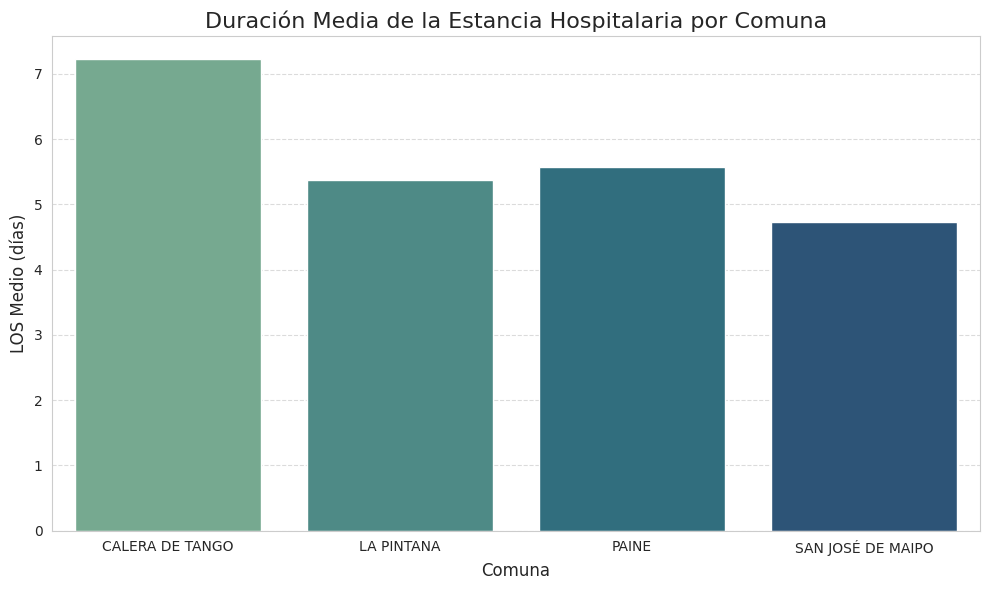

/tmp/ipykernel_2590/209420838.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Comuna')


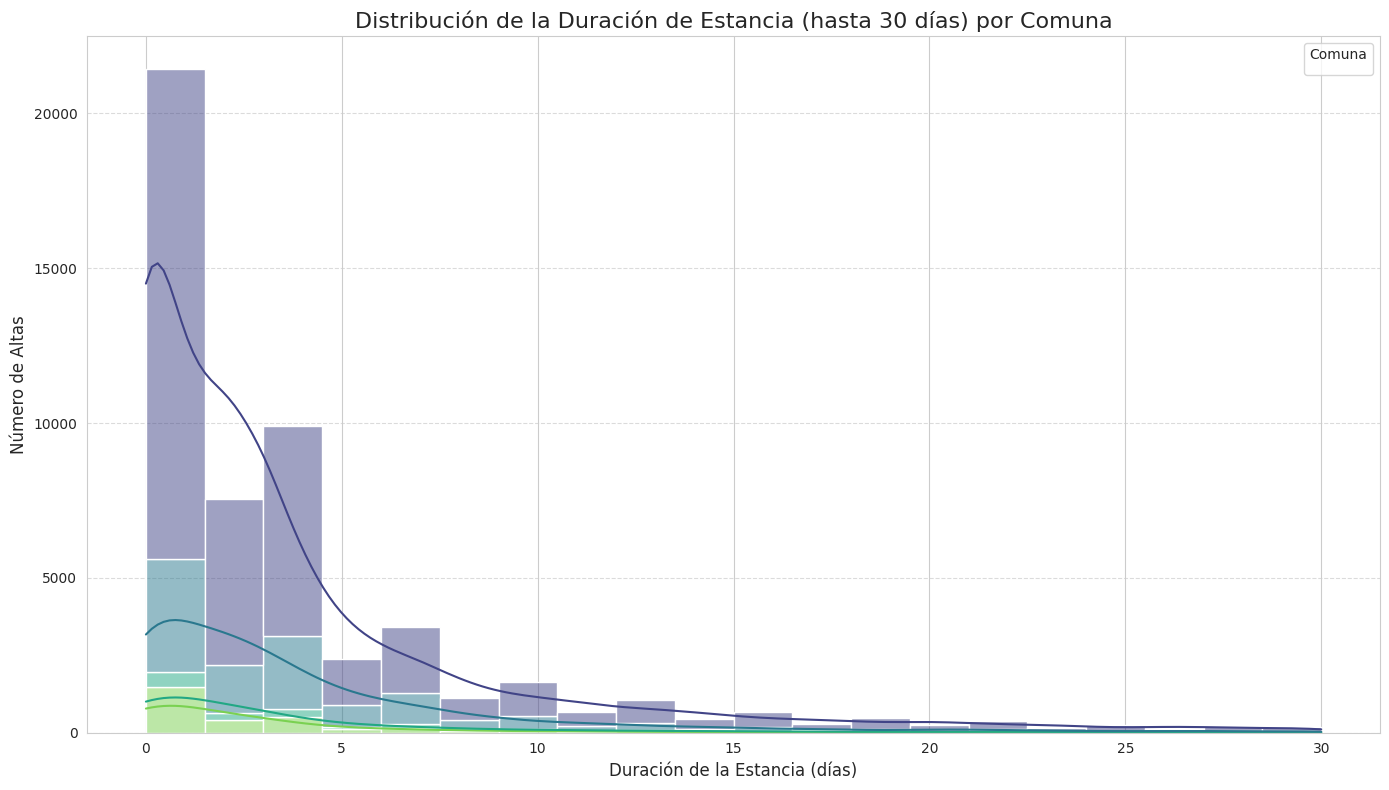

In [ ]:
# Calculate mean and median LOS per commune
los_summary_comuna = gr_com_specific.groupby('COMUNA')['los'].agg(['mean', 'median']).round(2).reset_index()

print("Media y Mediana de la Duración de la Estancia (días) por Comuna:")
display(los_summary_comuna)

plt.figure(figsize=(10, 6))
sns.barplot(data=los_summary_comuna, x='COMUNA', y='mean', hue='COMUNA', palette='crest', legend=False)
plt.title('Duración Media de la Estancia Hospitalaria por Comuna', fontsize=16)
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('LOS Medio (días)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribution of LOS (up to 30 days) by commune
plt.figure(figsize=(14, 8))
sns.histplot(data=gr_com_specific[gr_com_specific['los'] <= 30], x='los', hue='COMUNA',
             multiple='stack', bins=20, kde=True, palette='viridis')
plt.title('Distribución de la Duración de Estancia (hasta 30 días) por Comuna', fontsize=16)
plt.xlabel('Duración de la Estancia (días)', fontsize=12)
plt.ylabel('Número de Altas', fontsize=12)
plt.legend(title='Comuna')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
